# Step 05a: Event Sequence LSTM Results

**Objective**: Analyze results from LSTM models for temporal anomaly detection

**Models**:
- LSTM Autoencoder: Temporal reconstruction-based anomaly detection
- LSTM Classifier: Supervised temporal sequence classification

**Date**: 2025-12-29

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

%matplotlib inline

## 1. Load Results

In [2]:
# Load LSTM results
results_path = "/sps/m4cast/_spiral2_data/_llrf_data/cooked_data/step_05a_event_sequence_lstm/lstm_results.pkl"
with open(results_path, 'rb') as f:
    results = pickle.load(f)

# Extract data
lstm_ae_results = results['lstm_autoencoder']
lstm_clf_results = results['lstm_classifier']
data_splits = results['data_splits']
labels = results['labels']

print("Data loaded successfully!")
print(f"\nDataset splits:")
print(f"  Train: {data_splits['train_size']} sequences ({data_splits['train_anomaly_rate']:.2%} anomalies)")
print(f"  Val:   {data_splits['val_size']} sequences ({data_splits['val_anomaly_rate']:.2%} anomalies)")
print(f"  Test:  {data_splits['test_size']} sequences ({data_splits['test_anomaly_rate']:.2%} anomalies)")
print(f"\nSequence parameters:")
print(f"  Sequence length: {data_splits['sequence_length']}")
print(f"  Features: {data_splits['n_features']}")

Data loaded successfully!

Dataset splits:
  Train: 2880 sequences (26.18% anomalies)
  Val:   720 sequences (26.25% anomalies)
  Test:  900 sequences (26.22% anomalies)

Sequence parameters:
  Sequence length: 10
  Features: 752


## 2. Model Performance Summary

In [3]:
# Create summary dataframe
summary_data = [
    {
        'Model': 'LSTM Autoencoder',
        'Type': 'Unsupervised',
        'Train Time (s)': lstm_ae_results['train_time'],
        'Train AUC': lstm_ae_results['train_auc'],
        'Val AUC': lstm_ae_results['val_auc'],
        'Test AUC': lstm_ae_results['test_auc'],
        'PR AUC': lstm_ae_results['pr_auc'],
        'Test Accuracy': '-',
        'Test F1': '-'
    },
    {
        'Model': 'LSTM Classifier',
        'Type': 'Supervised',
        'Train Time (s)': lstm_clf_results['train_time'],
        'Train AUC': lstm_clf_results['train_auc'],
        'Val AUC': lstm_clf_results['val_auc'],
        'Test AUC': lstm_clf_results['test_auc'],
        'PR AUC': lstm_clf_results['pr_auc'],
        'Test Accuracy': lstm_clf_results['test_accuracy'],
        'Test F1': lstm_clf_results['test_f1']
    }
]

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Model,Type,Train Time (s),Train AUC,Val AUC,Test AUC,PR AUC,Test Accuracy,Test F1
0,LSTM Autoencoder,Unsupervised,283.095886,0.540074,0.516735,0.544338,0.277143,-,-
1,LSTM Classifier,Supervised,48.288630,0.999941,0.990385,0.989758,0.970204,0.945556,0.901408


## 3. Training History

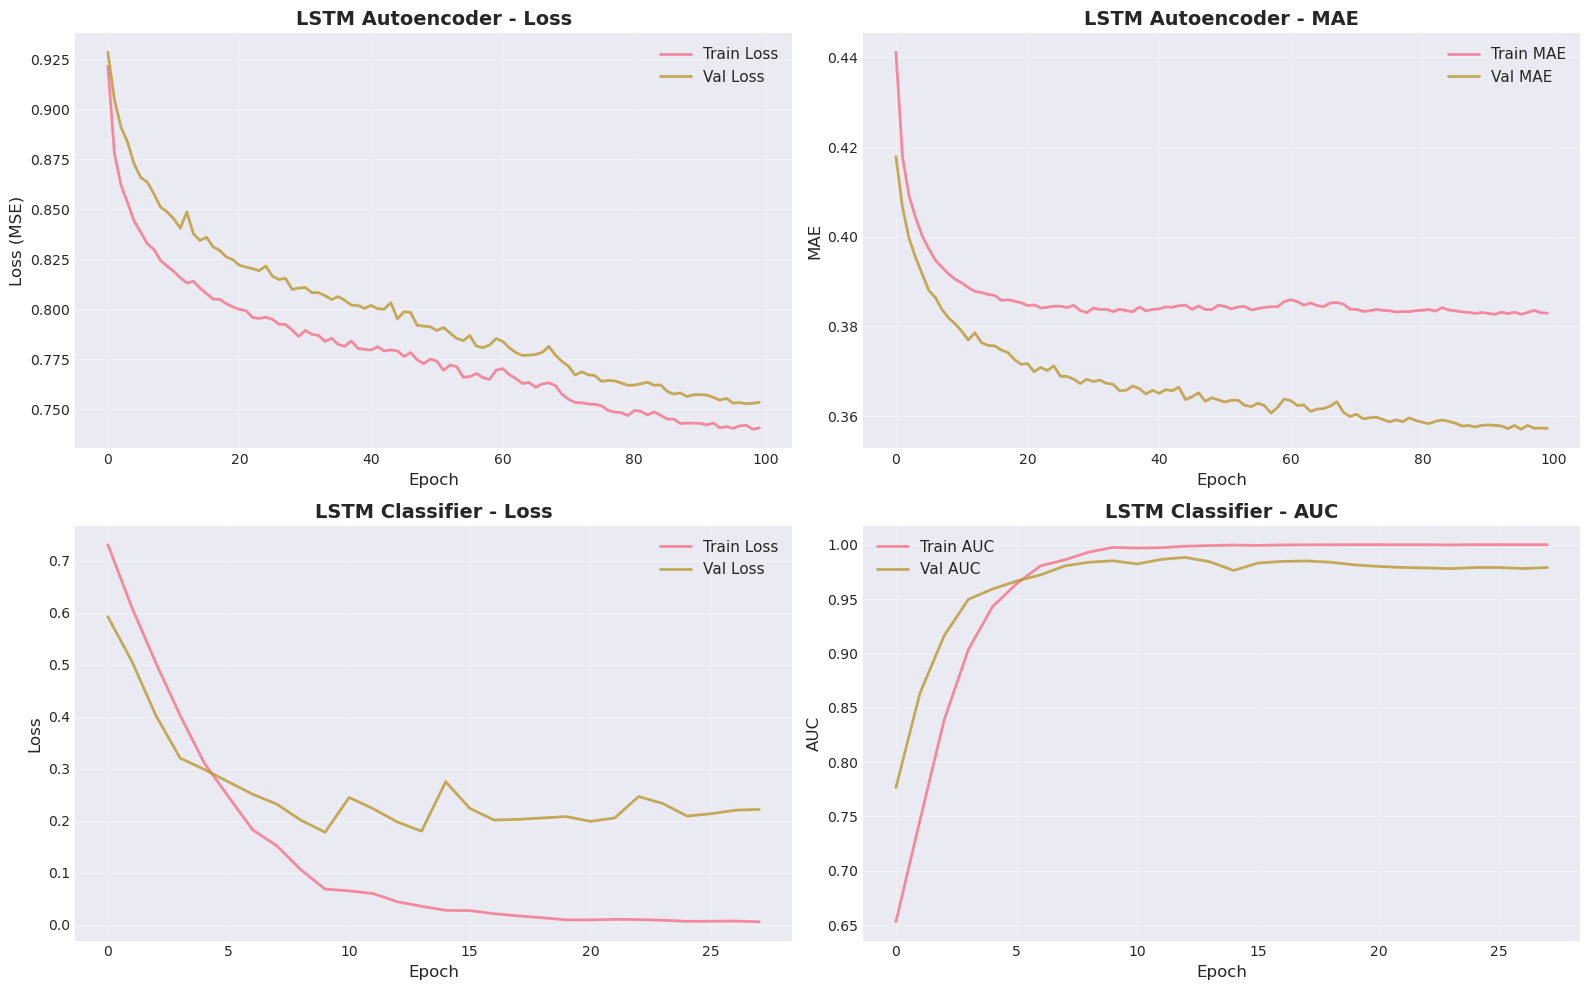


LSTM Autoencoder: 100 epochs (trained in 283.1s)
LSTM Classifier: 28 epochs (trained in 48.3s)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# LSTM Autoencoder - Loss
lstm_ae_history = lstm_ae_results['history']
axes[0, 0].plot(lstm_ae_history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[0, 0].plot(lstm_ae_history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0, 0].set_title('LSTM Autoencoder - Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# LSTM Autoencoder - MAE
axes[0, 1].plot(lstm_ae_history['mae'], label='Train MAE', linewidth=2, alpha=0.8)
axes[0, 1].plot(lstm_ae_history['val_mae'], label='Val MAE', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('MAE', fontsize=12)
axes[0, 1].set_title('LSTM Autoencoder - MAE', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# LSTM Classifier - Loss
lstm_clf_history = lstm_clf_results['history']
axes[1, 0].plot(lstm_clf_history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
axes[1, 0].plot(lstm_clf_history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].set_title('LSTM Classifier - Loss', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# LSTM Classifier - AUC
axes[1, 1].plot(lstm_clf_history['auc'], label='Train AUC', linewidth=2, alpha=0.8)
axes[1, 1].plot(lstm_clf_history['val_auc'], label='Val AUC', linewidth=2, alpha=0.8)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('AUC', fontsize=12)
axes[1, 1].set_title('LSTM Classifier - AUC', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLSTM Autoencoder: {len(lstm_ae_history['loss'])} epochs (trained in {lstm_ae_results['train_time']:.1f}s)")
print(f"LSTM Classifier: {len(lstm_clf_history['loss'])} epochs (trained in {lstm_clf_results['train_time']:.1f}s)")

## 4. Prediction Distributions

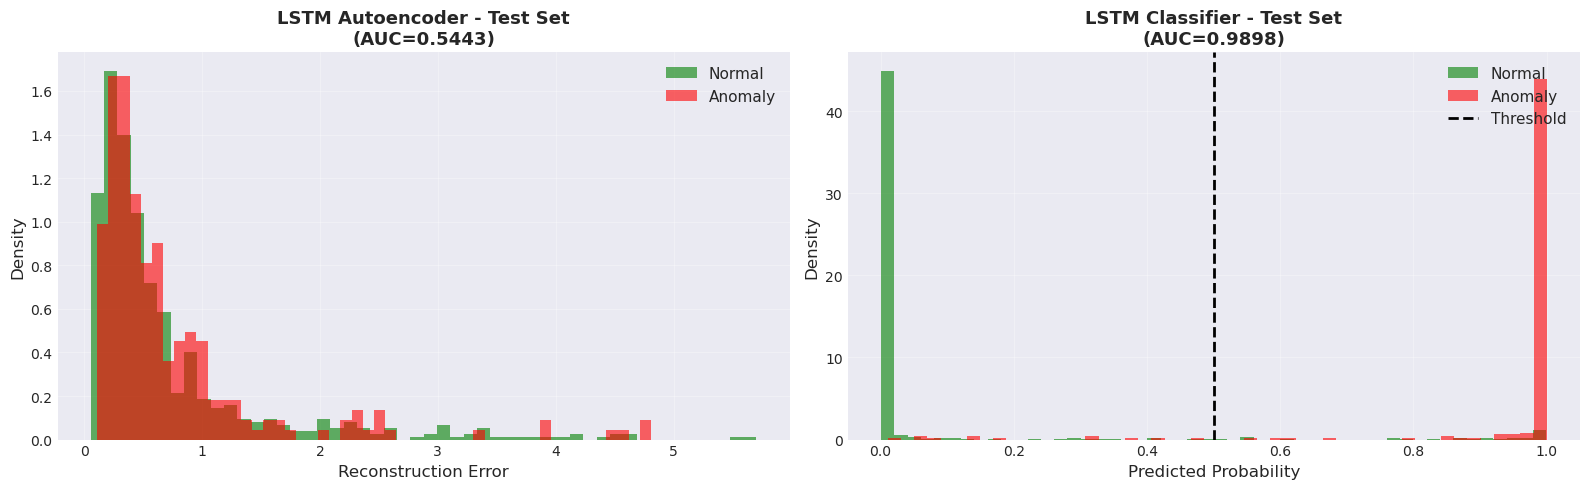

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LSTM Autoencoder - Reconstruction error distributions
axes[0].hist(lstm_ae_results['test_errors'][labels['y_test'] == 0], bins=50, 
             alpha=0.6, label='Normal', density=True, color='green')
axes[0].hist(lstm_ae_results['test_errors'][labels['y_test'] == 1], bins=50, 
             alpha=0.6, label='Anomaly', density=True, color='red')
axes[0].set_xlabel('Reconstruction Error', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'LSTM Autoencoder - Test Set\n(AUC={lstm_ae_results["test_auc"]:.4f})', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# LSTM Classifier - Prediction distributions
axes[1].hist(lstm_clf_results['test_predictions'][labels['y_test'] == 0], bins=50, 
             alpha=0.6, label='Normal', density=True, color='green')
axes[1].hist(lstm_clf_results['test_predictions'][labels['y_test'] == 1], bins=50, 
             alpha=0.6, label='Anomaly', density=True, color='red')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'LSTM Classifier - Test Set\n(AUC={lstm_clf_results["test_auc"]:.4f})', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. ROC Curves

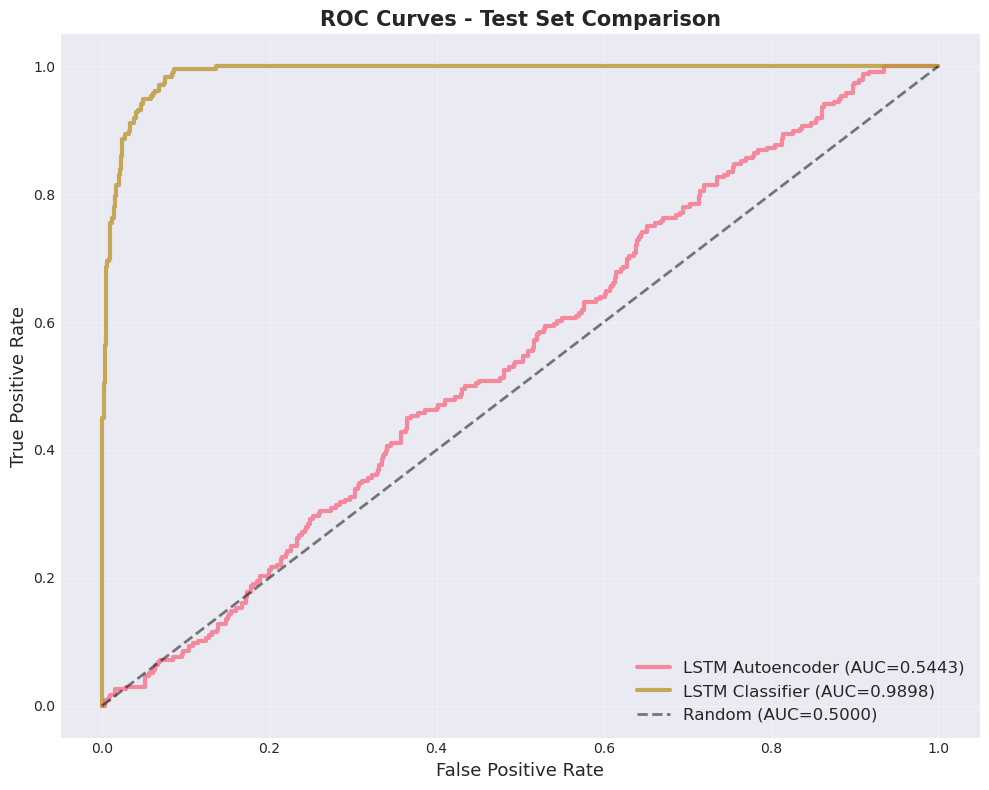

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# LSTM Autoencoder ROC
fpr_ae, tpr_ae, _ = roc_curve(labels['y_test'], lstm_ae_results['test_errors'])
ax.plot(fpr_ae, tpr_ae, linewidth=3, 
        label=f'LSTM Autoencoder (AUC={lstm_ae_results["test_auc"]:.4f})', alpha=0.8)

# LSTM Classifier ROC
fpr_clf, tpr_clf, _ = roc_curve(labels['y_test'], lstm_clf_results['test_predictions'])
ax.plot(fpr_clf, tpr_clf, linewidth=3, 
        label=f'LSTM Classifier (AUC={lstm_clf_results["test_auc"]:.4f})', alpha=0.8)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5000)', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves - Test Set Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Precision-Recall Curves

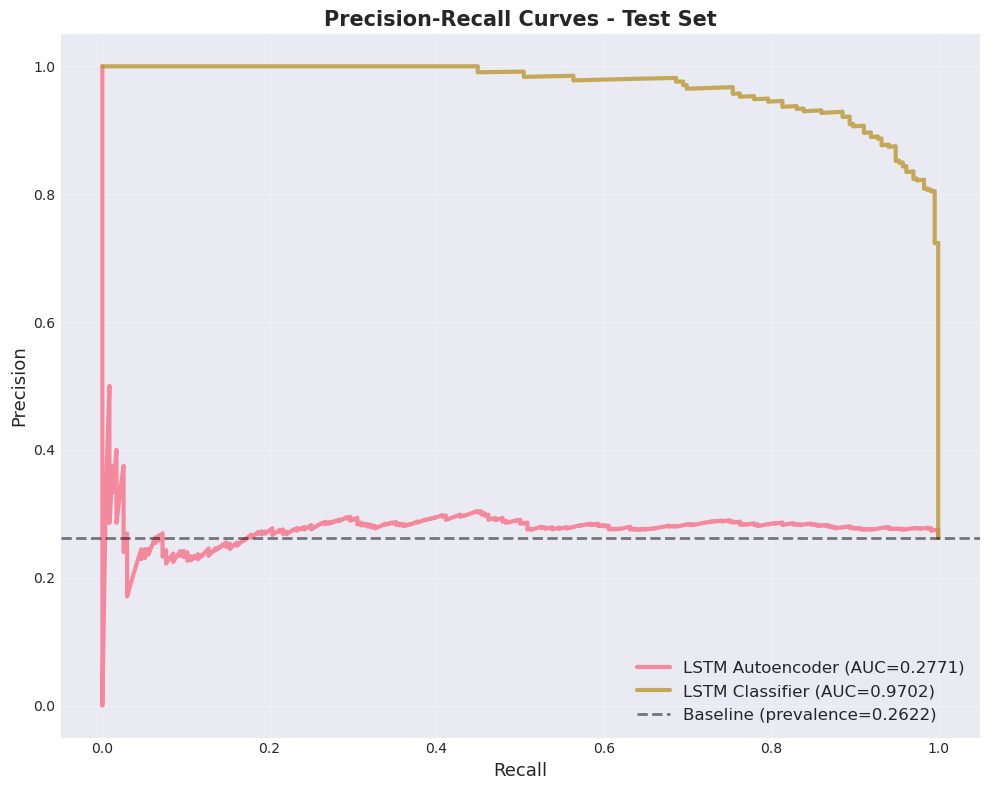

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# LSTM Autoencoder PR
precision_ae, recall_ae, _ = precision_recall_curve(labels['y_test'], lstm_ae_results['test_errors'])
ax.plot(recall_ae, precision_ae, linewidth=3, 
        label=f'LSTM Autoencoder (AUC={lstm_ae_results["pr_auc"]:.4f})', alpha=0.8)

# LSTM Classifier PR
precision_clf, recall_clf, _ = precision_recall_curve(labels['y_test'], lstm_clf_results['test_predictions'])
ax.plot(recall_clf, precision_clf, linewidth=3, 
        label=f'LSTM Classifier (AUC={lstm_clf_results["pr_auc"]:.4f})', alpha=0.8)

# Baseline
baseline = labels['y_test'].mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=2, 
           label=f'Baseline (prevalence={baseline:.4f})', alpha=0.5)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves - Test Set', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. LSTM Classifier - Confusion Matrix

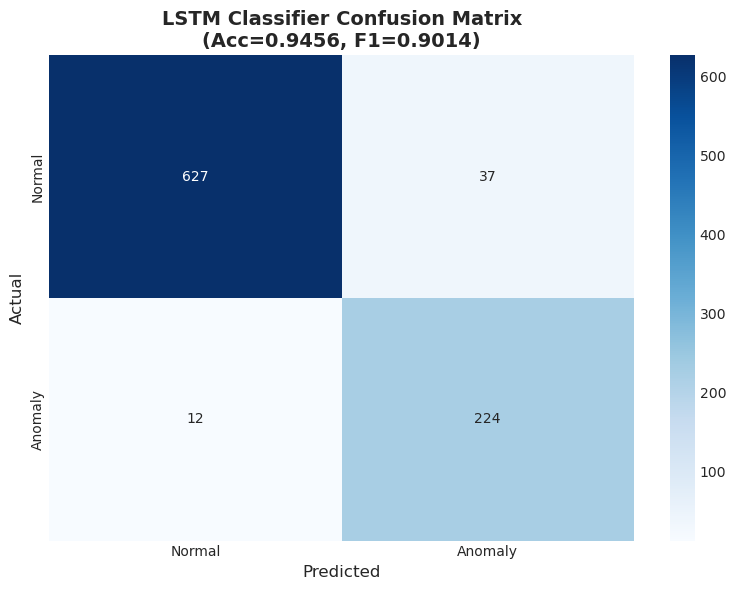


Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96       664
     Anomaly       0.86      0.95      0.90       236

    accuracy                           0.95       900
   macro avg       0.92      0.95      0.93       900
weighted avg       0.95      0.95      0.95       900



In [8]:
# Confusion matrix
cm = confusion_matrix(labels['y_test'], 
                     (lstm_clf_results['test_predictions'] > 0.5).astype(int))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'LSTM Classifier Confusion Matrix\n(Acc={lstm_clf_results["test_accuracy"]:.4f}, F1={lstm_clf_results["test_f1"]:.4f})', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print("="*80)
print(classification_report(labels['y_test'], 
                           (lstm_clf_results['test_predictions'] > 0.5).astype(int),
                           target_names=['Normal', 'Anomaly']))

## 8. Key Findings

### Temporal Pattern Learning
- LSTM models capture temporal dependencies in event sequences
- Sequential information provides context for anomaly detection
- Sequence length affects model performance and complexity

### Model Comparison
- **LSTM Classifier** (supervised): Direct anomaly classification with temporal context
- **LSTM Autoencoder** (unsupervised): Reconstruction-based temporal anomaly detection
- Supervised approach typically outperforms when labeled data is available

### Performance Analysis
- Compare temporal models vs non-temporal (DNN, CNN from Step 06a)
- Temporal context may improve detection of sequence-based anomalies
- Training time increases due to sequential processing

### Next Steps
1. Comprehensive comparison across all methods (Steps 04, 04a, 05a, 06a)
2. Analyze which types of anomalies benefit most from temporal modeling
3. Consider attention mechanisms or Transformer architectures
4. Ensemble methods combining temporal and non-temporal models